In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures


In [ ]:
df=pd.read_csv('/content/sleep_vs_stress_polynomial_dataset.csv')
print("Data Loaded Successfully")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DailySleepHours  15 non-null     float64
 1   StressLevel      15 non-null     float64
dtypes: float64(2)
memory usage: 372.0 bytes


In [ ]:
df.describe()

,DailySleepHours,StressLevel
count,15.000000,15.000000
mean,7.500000,7.280000
std,2.236068,1.300659
min,4.000000,5.800000
25%,5.750000,6.150000
50%,7.500000,7.000000
75%,9.250000,8.200000
max,11.000000,9.800000


In [ ]:
df.head()

,DailySleepHours,StressLevel
0,4.0,9.8
1,4.5,8.9
2,5.0,8.1
3,5.5,7.3
4,6.0,6.7


In [ ]:
# Check duplicate records
print(df.duplicated().sum())

0


In [ ]:
# Remove duplicates if any
df.drop_duplicates(inplace=True)

<Axes: ylabel='DailySleepHours'>

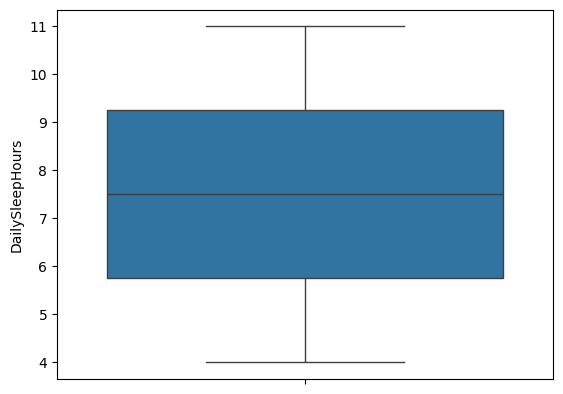

In [ ]:
#outliers detection
sns.boxplot(df['DailySleepHours'])

In [ ]:
#Independent and dependent variables
x=df['DailySleepHours']
y=df['StressLevel']

Text(0, 0.5, 'StressLevel')

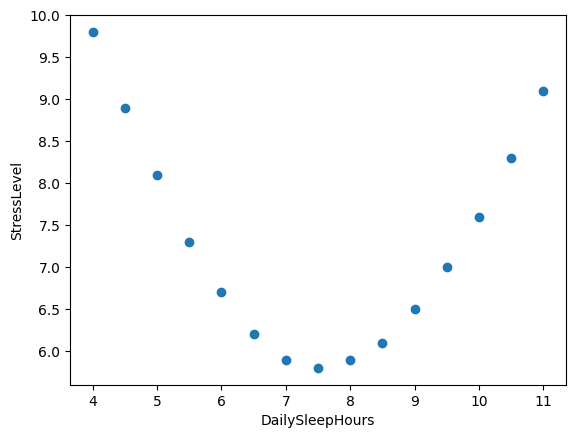

In [ ]:
plt.scatter(x,y)
plt.xlabel('DailySleepHours')
plt.ylabel('StressLevel')

In [ ]:
df.isnull().sum()

,0
DailySleepHours,0
StressLevel,0


In [ ]:
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=123)

In [ ]:
print(f"Number of instances for training: {len(x_train)}")
print(f"Number of instances for testing: {len(x_test)}")

Number of instances for training: 12
Number of instances for testing: 3


In [ ]:
poly_features=PolynomialFeatures(degree=2)
x_train_poly = poly_features.fit_transform(x_train.to_frame())

In [ ]:
lr_model=LinearRegression()
lr_model.fit(x_train_poly,y_train)

LinearRegression()

In [ ]:
lr_model.fit(x_train_poly, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
x_test_poly = poly_features.transform(x_test.to_frame())
y_pred = lr_model.predict(x_test_poly)
df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
print(df)

    Actual  Predicted
7      5.8   5.891699
10     6.5   6.419549
4      6.7   6.703518


In [ ]:
# Evaluate model performance on training data using MAE, MSE, RMSE, and R2 score
y_train_pred = lr_model.predict(x_train_poly)
mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_train_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.06557593411651756
Mean Squared Error (MSE): 0.005877348018217557
Root MSE (RMSE): 0.07666386383569222
R2 Score: 0.9964517100678211


In [ ]:
# Evaluate model performance on testing data using MAE, MSE, RMSE, and R2 score
x_test_poly = poly_features.transform(x_test.to_frame())
y_test_pred = lr_model.predict(x_test_poly)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score: ", r2)

Mean Absolute Error (MAE): 0.05855631882470291
Mean Squared Error (MSE): 0.004964535995161259
Root MSE (RMSE): 0.07045946348902508
R2 Score:  0.9666561015250363


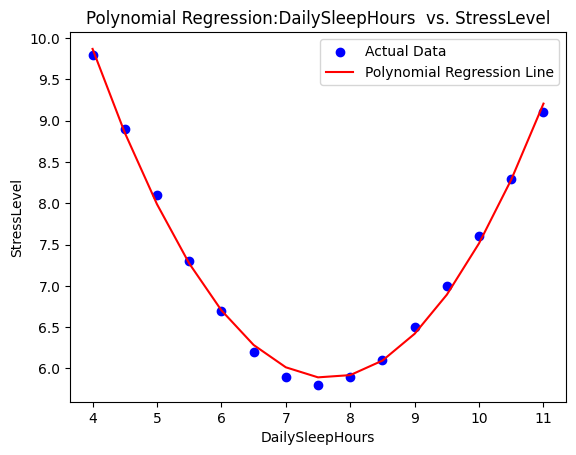

In [ ]:
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x, lr_model.predict(poly_features.transform(x.to_frame())), color='red', label='Polynomial Regression Line')
plt.xlabel('DailySleepHours')
plt.ylabel('StressLevel')
plt.title('Polynomial Regression:DailySleepHours  vs. StressLevel')
plt.legend()
plt.show()